In [28]:
import csv
import datetime
import os
from math import pi

import numpy as np
import requests
from dotenv import load_dotenv
from matplotlib import pyplot as plt
from skyfield.api import EarthSatellite, load, wgs84

In [29]:
ts = load.timescale()

# Alive orbcomm satellites

FM4


FM5
FM6
FM7
FM8
FM9
FM10
FM11
FM12


FM13
FM14
FM15
FM18
FM19
FM20


FM21
FM23
FM27

FM30
FM31
FM32 (?)
FM34
FM35


FM103
FM107
FM109

FM108
FM110
FM112
FM113
FM114
FM115
FM116
FM117
FM118



In [30]:
load_dotenv()
space_track_credentials = {}
space_track_credentials['username'] = os.getenv('SPACE_TRACK_USERNAME')
space_track_credentials['password'] = os.getenv('SPACE_TRACK_PASSWORD')


In [31]:
with requests.session() as session:
    login_url = "https://www.space-track.org/ajaxauth/login"
    payload = {
        'identity': space_track_credentials['username'],
        'password': space_track_credentials['password']
    }
    session.post(login_url, data=payload)
    omm_csv = session.get("https://www.space-track.org/basicspacedata/query/class/gp/OBJECT_NAME/~~ORBCOMM%25/orderby/OBJECT_NAME%20asc/format/csv/emptyresult/show")

csv_reader = csv.reader(omm_csv.text.strip().splitlines())
header = next(csv_reader)



In [32]:
sats = []

for row in csv_reader:
    element_dict = dict(zip(header, row, strict=True))
    if not element_dict["OBJECT_NAME"].strip().endswith("DEB") and "FM" in element_dict["OBJECT_NAME"].strip():
        sats.append(EarthSatellite.from_omm(ts, element_dict))
print('Loaded', len(sats), 'satellites')
for sat in sats:
    print(sat.name, sat.model.satnum)

Loaded 58 satellites
ORBCOMM FM 1 23545
ORBCOMM FM 10 25113
ORBCOMM FM 103 40091
ORBCOMM FM 104 40090
ORBCOMM FM 105 41181
ORBCOMM FM 106 40088
ORBCOMM FM 107 40087
ORBCOMM FM 108 41187
ORBCOMM FM 109 40086
ORBCOMM FM 11 25114
ORBCOMM FM 110 41182
ORBCOMM FM 111 40089
ORBCOMM FM 112 41184
ORBCOMM FM 113 41185
ORBCOMM FM 114 41179
ORBCOMM FM 115 41186
ORBCOMM FM 116 41189
ORBCOMM FM 117 41188
ORBCOMM FM 118 41183
ORBCOMM FM 119 41180
ORBCOMM FM 12 25115
ORBCOMM FM 13 25420
ORBCOMM FM 14 25419
ORBCOMM FM 15 25418
ORBCOMM FM 16 25417
ORBCOMM FM 17 25413
ORBCOMM FM 18 25414
ORBCOMM FM 19 25415
ORBCOMM FM 2 23546
ORBCOMM FM 20 25416
ORBCOMM FM 21 25475
ORBCOMM FM 22 25476
ORBCOMM FM 23 25477
ORBCOMM FM 24 25478
ORBCOMM FM 25 25479
ORBCOMM FM 26 25480
ORBCOMM FM 27 25481
ORBCOMM FM 28 25482
ORBCOMM FM 29 33062
ORBCOMM FM 3 25158
ORBCOMM FM 30 25980
ORBCOMM FM 31 25981
ORBCOMM FM 32 25982
ORBCOMM FM 33 25983
ORBCOMM FM 34 25986
ORBCOMM FM 35 25985
ORBCOMM FM 36 25984
ORBCOMM FM 37 33064
ORBCO

In [33]:
active_sat_names_str = '''FM4 FM5 FM6 FM7 FM8 FM9 FM10 FM11 FM12 FM13 FM14 FM15 FM18 FM19 FM20 FM21 FM23 FM27 FM30 FM31
FM32 FM34 FM35 FM103 FM107 FM109 FM108 FM110 FM112 FM113 FM114 FM115 FM116 FM117 FM118'''  # FM32 maybe inactive
active_sat_names = [x[0:2] + ' ' + x[2:] for x in active_sat_names_str.split()]
print(active_sat_names)

active_sats = [sat for sat in sats if sat.name.endswith(tuple(active_sat_names))]

print(len(active_sats), 'active satellites')
print(len(sats), 'total satellites')
print(len(active_sat_names), 'active satellite names')

sats = active_sats


['FM 4', 'FM 5', 'FM 6', 'FM 7', 'FM 8', 'FM 9', 'FM 10', 'FM 11', 'FM 12', 'FM 13', 'FM 14', 'FM 15', 'FM 18', 'FM 19', 'FM 20', 'FM 21', 'FM 23', 'FM 27', 'FM 30', 'FM 31', 'FM 32', 'FM 34', 'FM 35', 'FM 103', 'FM 107', 'FM 109', 'FM 108', 'FM 110', 'FM 112', 'FM 113', 'FM 114', 'FM 115', 'FM 116', 'FM 117', 'FM 118']
35 active satellites
58 total satellites
35 active satellite names


In [37]:
# Filter by inclination
incl_filtered_sats = []
for sat in sats:
    if sat.model.inclo * (180 / pi) > 50.0:
        print(sat.name, sat.model.inclo * (180 / pi))
        incl_filtered_sats.append(sat)
sats = incl_filtered_sats

ORBCOMM FM 4 107.9604


In [38]:
def polar_plot(alts, azs, name):
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    alts = [90 - alt for alt in alts]
    azs = [np.radians(az) for az in azs]
    ax.scatter(azs, alts, s=10)
    ax.set_theta_zero_location('N')
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(0, 90)
    ax.set_yticks(range(0, 91, 30))
    ax.set_yticklabels(range(90, -1, -30))
    ax.set_xticks(np.radians(range(0, 360, 30)))
    ax.set_title(name)
    return fig

In [39]:
satellite = sats[0]

qth = wgs84.latlon(55.5269, 37.0888, elevation_m=172.0)
t0 = ts.utc(2026, 9, 3)
t1 = ts.utc(2026, 10, 3)

In [ ]:
def plot_satellite(satellite, qth, t0, t1):
    t, events = satellite.find_events(qth, t0, t1, altitude_degrees=0.0)
    precision_sec = 5
    intervals = []
    for ti, event in zip(t, events, strict=True):
        if event == 0:
            intervals.append([
                ti.utc_datetime(),
                None
            ])
        elif event == 2:
            intervals[-1][1] = ti.utc_datetime()

    totalalts, totalazs = [], []

    for start, end in intervals:
        times = [
            start + datetime.timedelta(seconds=precision_sec * i)
            for i in range(
                int((end - start).total_seconds() // precision_sec) + 1
            )
        ]

        skyfield_times = ts.from_datetimes(times)

        satellite_position = satellite.at(skyfield_times)
        observer_position = qth.at(skyfield_times)
        topocentric = satellite_position - observer_position

        alts, azs, _ = topocentric.altaz()
        totalalts.extend(alts.degrees)
        totalazs.extend(azs.degrees)

    return polar_plot(totalalts, totalazs, satellite.name)

/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_3115/1927176205.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, qth, t0, t1).show()


Satellite: ORBCOMM FM 4


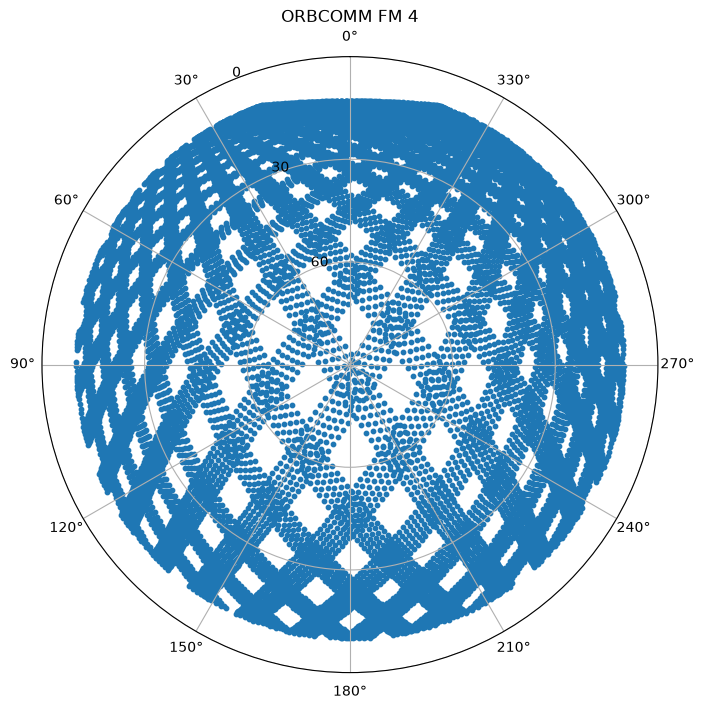

In [41]:
%matplotlib inline
for satellite in sats:
    plot_satellite(satellite, qth, t0, t1).show()

for satellite in sorted(sats, key=lambda s: s.name):
    print(f"Satellite: {satellite.name}")

In [44]:
m2_3_csv = requests.get("https://retlector.eu/57166/csv")
m2_4_csv = requests.get("https://retlector.eu/59051/csv")

csv_reader_m2_3 = csv.reader(m2_3_csv.text.strip().splitlines())
csv_reader_m2_4 = csv.reader(m2_4_csv.text.strip().splitlines())
header = next(csv_reader_m2_3)
next(csv_reader_m2_4)

meteors = []

meteors.append(EarthSatellite.from_omm(ts, dict(zip(header, next(csv_reader_m2_3), strict=True))))
meteors.append(EarthSatellite.from_omm(ts, dict(zip(header, next(csv_reader_m2_4), strict=True))))
print('Loaded', len(meteors), 'satellites')

Loaded 2 satellites


/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_3115/2173323630.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, qth, t0, t1).show()
/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_3115/2173323630.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, qth, t0, t1).show()


Satellite: METEOR-M2 3
Satellite: METEOR-M2 4


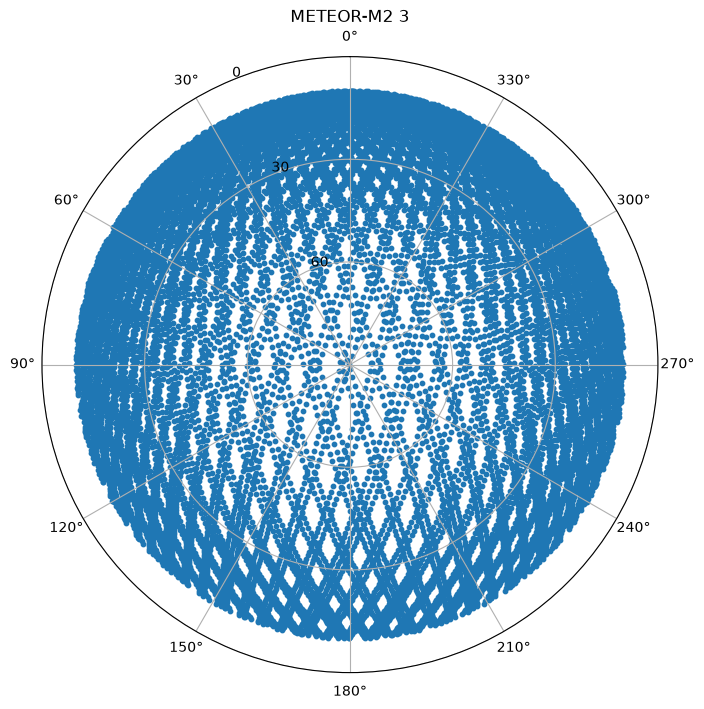

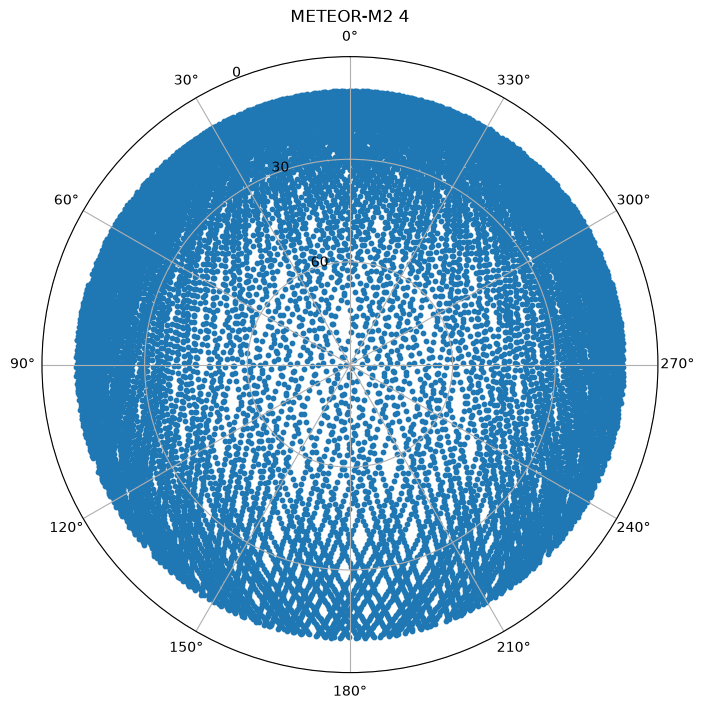

In [45]:
%matplotlib inline
for satellite in meteors:
    plot_satellite(satellite, qth, t0, t1).show()

for satellite in sorted(meteors, key=lambda s: s.name):
    print(f"Satellite: {satellite.name}")